# 🐍 CNN para Identificação de Animais Venenosos
## Treinamento do Zero com Otimização via Optuna

Este notebook treina uma CNN do zero para classificar animais em:
- **Venenoso** (cobra venenosa, aranha, escorpião, medusa, etc.)
- **Não-venenoso** (animais seguros)

Pipeline completo:
1. Download e preparação dos dados
2. Arquitetura CNN personalizada
3. Otimização de hiperparâmetros com **Optuna**
4. Treinamento final
5. Métricas e visualizações
6. Exportação do modelo para a API FastAPI

In [ ]:
# -- Instalação de dependências -- Retirar py -m se não estiver usando pymanager
!py -m pip install torch torchvision optuna matplotlib seaborn scikit-learn torchmetrics tqdm pillow requests -q

'pip' não é reconhecido como um comando interno
ou externo, um programa operável ou um arquivo em lotes.


## 1. Preparação dos Dados

Foi utilizado o dataset [**Venomous and Non-venomous Animals**](https://www.kaggle.com/datasets/adityasharma01/snake-dataset-india/data) disponível no Kaggle.

In [1]:
import torch.nn as nn
import torch
import torchmetrics
from torch.utils.data import DataLoader, random_split

from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

import optuna
import numpy as np

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Reproducibilidade

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
torch.cuda.manual_seed(seed)

In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])



train_dataset = ImageFolder('data/train', transform=train_transforms)
val_dataset   = ImageFolder('data/train', transform=test_transforms)


indices = list(range(len(train_dataset)))
labels = train_dataset.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=seed
)

train_dataset = Subset(train_dataset, train_idx)
val_dataset = Subset(val_dataset, val_idx)

dataset_test = ImageFolder('data/test', transform=test_transforms)


## 2. Definindo arquitetura do modelo e Treinando

In [3]:
def create_model(num_classes, freeze_backbone):
    model = resnet18(pretrained=True)

    # 1. Substituir a última camada
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    # 2. Congelar (ou não)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

        # liberar só o classificador
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

In [5]:
metric = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)

def objective(trial):
    metric.reset()

    # Hiperparâmetros a serem otimizados
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    num_epochs = trial.suggest_int('num_epochs', 10, 50)

    freeze_backbone = trial.suggest_categorical("freeze", [True, False])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Inicializar o modelo, critério de perda e otimizador
    model = create_model(2, freeze_backbone).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    # Treinar o modelo
    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Avaliar o modelo
    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1)

            metric.update(preds, labels)
    accuracy = metric.compute()
    return accuracy

In [6]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print("Melhores hiperparâmetros encontrados:", best_params)
best_acc = study.best_value
print(f"Melhor acurácia de validação: {best_acc:.4f}")

[I 2026-04-15 00:23:23,321] A new study created in memory with name: no-name-64ef759b-e1b9-41cf-a7bb-99119ee75c60


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\migue\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\migue\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\migue/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 61.3MB/s]


[I 2026-04-15 00:25:36,612] Trial 0 finished with value: 0.7323943376541138 and parameters: {'learning_rate': 0.002477571061654014, 'batch_size': 32, 'num_epochs': 29, 'freeze': True}. Best is trial 0 with value: 0.7323943376541138.
[I 2026-04-15 00:26:27,326] Trial 1 finished with value: 0.8309859037399292 and parameters: {'learning_rate': 3.15503969534913e-05, 'batch_size': 64, 'num_epochs': 11, 'freeze': False}. Best is trial 1 with value: 0.8309859037399292.
[I 2026-04-15 00:27:59,785] Trial 2 finished with value: 0.7492957711219788 and parameters: {'learning_rate': 0.0010993553721937459, 'batch_size': 64, 'num_epochs': 21, 'freeze': True}. Best is trial 1 with value: 0.8309859037399292.
[I 2026-04-15 00:29:23,866] Trial 3 finished with value: 0.7436619997024536 and parameters: {'learning_rate': 0.0025829288128302354, 'batch_size': 64, 'num_epochs': 20, 'freeze': True}. Best is trial 1 with value: 0.8309859037399292.
[I 2026-04-15 00:30:21,086] Trial 4 finished with value: 0.763380

In [7]:
import json

with open('best_params.json', 'w') as f:
    json.dump(best_params, f)

In [8]:
study.trials_dataframe().to_csv('optuna_trials.csv', index=False)

## 3. Ultimo treinamento com hiperparamêtros corretos

In [5]:
import json
best_params = json.load(open('best_params.json'))

model = create_model(2, best_params['freeze']).to(device)

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_params['learning_rate']
)

num_epochs = best_params['num_epochs']
model.train()
for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

for epoch in range(num_epochs):
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

c:\Users\migue\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\migue\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 4. Testagem

In [9]:
model.eval()
acc = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
f1_score = torchmetrics.F1Score(task="multiclass", num_classes=2).to(device)

acc.reset()
f1_score.reset()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)
        acc.update(preds, labels)
        f1_score.update(preds, labels)

final_acc = acc.compute()
final_f1 = f1_score.compute()

print(f"Acurácia final no conjunto de validação: {final_acc:.4f}")
print(f"F1-Score final no conjunto de validação: {final_f1:.4f}")

torch.save(model.state_dict(), 'best_model.pt')

Acurácia final no conjunto de validação: 1.0000
F1-Score final no conjunto de validação: 1.0000


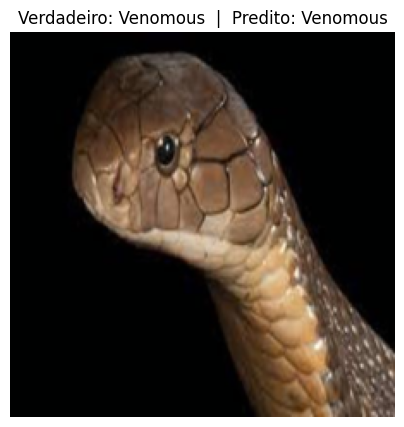

Imagem utilizada: data/test\Venomous\5.jpg
Predição: Venomous
Rótulo verdadeiro: Venomous


In [12]:
import random

import matplotlib.pyplot as plt

model.eval()

idx = random.randrange(len(dataset_test))
image_tensor, true_label = dataset_test[idx]
image_path = dataset_test.samples[idx][0]

with torch.no_grad():
    input_tensor = image_tensor.unsqueeze(0).to(device)
    logits = model(input_tensor)
    pred = logits.argmax(dim=1).item()

class_names = dataset_test.classes
pred_name = class_names[pred]
true_name = class_names[true_label]

inv_mean = [-m / s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
inv_std = [1 / s for s in [0.229, 0.224, 0.225]]
inv_normalize = transforms.Normalize(mean=inv_mean, std=inv_std)

img_vis = inv_normalize(image_tensor).cpu().clamp(0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(img_vis.permute(1, 2, 0))
plt.title(f"Verdadeiro: {true_name}  |  Predito: {pred_name}")
plt.axis("off")
plt.show()

print(f"Imagem utilizada: {image_path}")
print(f"Predição: {pred_name}")
print(f"Rótulo verdadeiro: {true_name}")

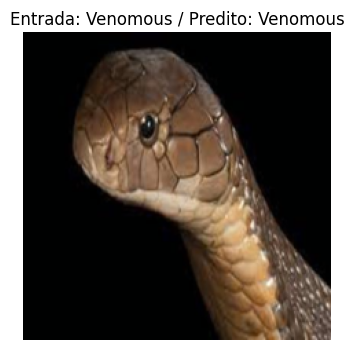

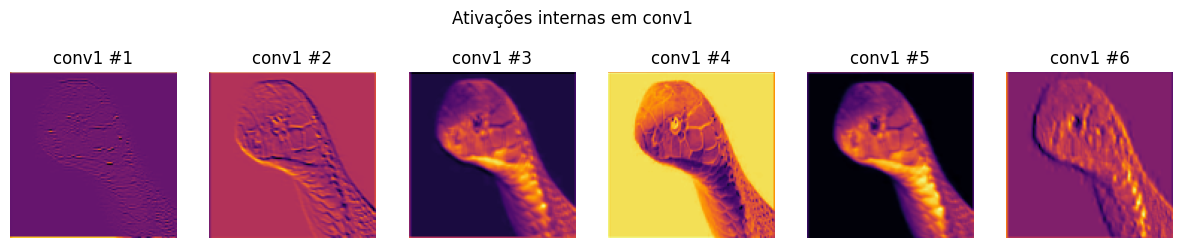

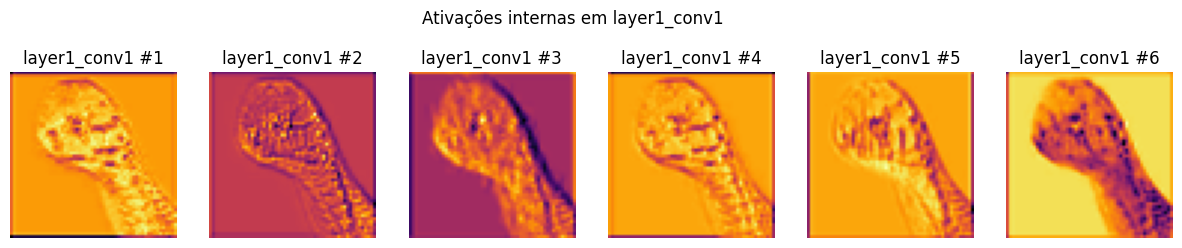

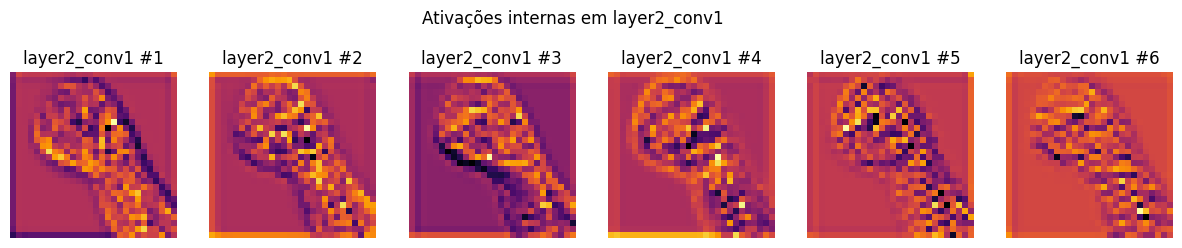

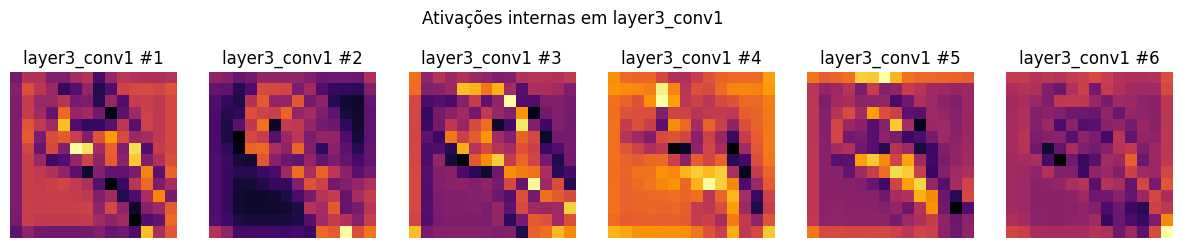

In [13]:
model.eval()

# mostra a imagem de entrada usada para gerar as ativações
plt.figure(figsize=(4, 4))
plt.imshow(img_vis.permute(1, 2, 0))
plt.title(f"Entrada: {true_name} / Predito: {pred_name}")
plt.axis("off")
plt.show()

activation = {}
def get_activation(name):
    def hook(module, input, output):
        activation[name] = output.detach()
    return hook

handles = []
for name, layer in [
    ("conv1", model.conv1),
    ("layer1_conv1", model.layer1[0].conv1),
    ("layer2_conv1", model.layer2[0].conv1),
    ("layer3_conv1", model.layer3[0].conv1),
]:
    handles.append(layer.register_forward_hook(get_activation(name)))

with torch.no_grad():
    _ = model(input_tensor)

for name, act in activation.items():
    fmap = act.squeeze(0).cpu()
    n = min(6, fmap.shape[0])

    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(f"Ativações internas em {name}")
    for i in range(n):
        ax = axes[i] if n > 1 else axes
        ax.imshow(fmap[i], cmap="inferno")
        ax.axis("off")
        ax.set_title(f"{name} #{i+1}")
    plt.show()

for h in handles:
    h.remove()